In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.interpolate import UnivariateSpline
from braid_analysis import flymath
import pynumdiff

from align_course_direction_analysis import unifying_algo_analysis as uaa

import figurefirst as fifi

In [2]:
import pandas as pd
import numpy as np

# Method 1: Using pandas (recommended - easiest to work with)
def load_with_pandas(filepath):
    """
    Load the .dat file using pandas
    Returns a DataFrame with column names and data
    """
    df = pd.read_csv(filepath, sep=r'\s+')
    return df

# Method 2: Using numpy
def load_with_numpy(filepath):
    """
    Load the .dat file using numpy
    Returns a structured array or regular array
    Note: This file has variable columns per row, so we'll use pandas internally
    """
    # For this file with varying columns, pandas handles it better
    # But we can convert to numpy array
    import pandas as pd
    df = pd.read_csv(filepath, sep=r'\s+')
    
    # Convert to numpy array
    data = df.values
    headers = df.columns.tolist()
    
    return data, headers

In [3]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))

# Explore the data

In [4]:
from pathlib import Path

dat_files = list(Path("wind100/turbulent").glob("*.dat"))


In [5]:
len(dat_files)

0

In [6]:
N = 36 # perfect square
fig = plt.figure( figsize=(10,10) )
Set = 0*N
for i in range(Set, N+Set):
    if i > len(dat_files) - 1:
        break
        
    ax = fig.add_subplot( int(np.sqrt(N)), int(np.sqrt(N)),i+1-Set)

    fname = dat_files[i]
    df = load_with_pandas(fname)
    ax.plot(df.x, df.y)
    
    ax.set_aspect('equal')
    fifi.mpl_functions.adjust_spines(ax, [])
    ax.set_title(fname)
    fifi.mpl_functions.set_fontsize(ax, 6)


<Figure size 1000x1000 with 0 Axes>

### Parameters

In [7]:
fname = 'turbulent/20march09q.dat'
df = load_with_pandas(fname)

flow_direction = 0
flow_condition = 'turbulent'
flow_speed = 1
body_length = 0.04
locomotion = 'walking'
medium = 'air'
group = 'terrestrial'

interp_dt = 0.01

FileNotFoundError: [Errno 2] No such file or directory: 'turbulent/20march09q.dat'

### Get time stamps and speed -- this is custom per data type

In [12]:
df_calibrated = df[['x', 'y']].copy()
df_calibrated.x /= 100
df_calibrated.y /= 100

df_calibrated['timestamps_sec'] = df.time

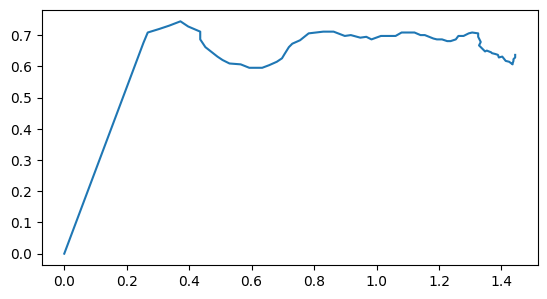

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.set_aspect('equal')

In [109]:
df_calibrated.x

0     1.48818
1     1.46062
2     1.44959
3     1.42479
4     1.40826
5     1.38897
6     1.37243
7     1.34763
8     1.32558
9     1.30078
10    1.26771
11    1.23739
12    1.20983
13    1.16574
14    1.11889
15    1.07755
16    1.04724
17    1.00865
18    0.96180
19    0.92873
20    0.90669
21    0.87913
22    0.85432
23    0.82677
24    0.79645
25    0.78267
26    0.75511
27    0.73307
28    0.70826
29    0.66968
30    0.64212
31    0.60078
32    0.56771
33    0.52913
34    0.48779
35    0.48504
36    0.46574
37    0.44370
38    0.42992
39    0.41338
40    0.39409
41    0.37480
42    0.35551
43    0.33071
44    0.30866
45    0.29212
46    0.28386
47    0.26732
48    0.25630
Name: x, dtype: float64

### Interpolate

In [126]:
interp_timestamps_sec = np.arange(0, df_calibrated.timestamps_sec.max(), interp_dt)

spline_x = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.x, s=1e-5, k=1)  # s=smoothing amount
interp_x = spline_x(interp_timestamps_sec)

spline_y = UnivariateSpline(df_calibrated.timestamps_sec, df_calibrated.y, s=1e-5, k=1)  # s=smoothing amount
interp_y = spline_y(interp_timestamps_sec)

df_calibrated_interp = pd.DataFrame({'timestamps_sec': interp_timestamps_sec,
                                     'x': interp_x,
                                     'y': interp_y})

### Parameters

In [127]:
df_calibrated_interp.shape

(400, 3)

In [128]:
tix_start = 100
tix_end = 390

1.0


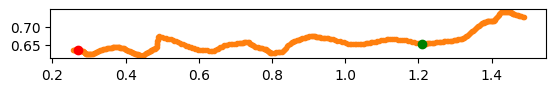

In [129]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.plot(df_calibrated.x.values, df_calibrated.y.values)
ax.plot(df_calibrated_interp.x.values, df_calibrated_interp.y.values, '.')

# when does search start
ax.plot(df_calibrated_interp.x.values[tix_start], df_calibrated_interp.y.values[tix_start], 'o', color='green')

# when does search end?
ax.plot(df_calibrated_interp.x.values[tix_end], df_calibrated_interp.y.values[tix_end], 'o', color='red')

print(df_calibrated_interp.timestamps_sec.values[tix_start])

ax.set_aspect('equal')

In [130]:
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
_, xvel = pynumdiff.savgoldiff(df_calibrated_interp.x, dt, [2, 3, 3])
_, yvel = pynumdiff.savgoldiff(df_calibrated_interp.y, dt, [2, 3, 3])

In [131]:
df_calibrated_interp['xvel'] = xvel
df_calibrated_interp['yvel'] = yvel
df_calibrated_interp['time_relative_to_flash'] = df_calibrated_interp['timestamps_sec'] - df_calibrated_interp.timestamps_sec.values[tix_start]
df_calibrated_interp['obj_id_unique_event'] = fname.split('.')[0]
df_calibrated_interp['obj_id_unique'] = fname.split('.')[0]
df_calibrated_interp = flymath.assign_course_and_ang_vel_to_dataframe(df_calibrated_interp)

df_calibrated_interp.course_smoothish -= flow_direction + np.pi
df_calibrated_interp.course_smoothish = wrap_angle(df_calibrated_interp.course_smoothish)

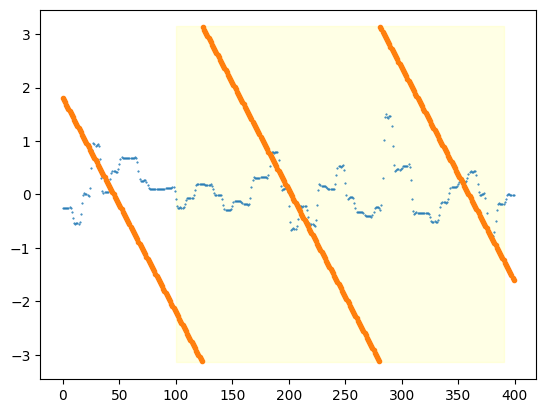

In [132]:
plt.plot(df_calibrated_interp.course_smoothish, '.', markersize=1)

ix = df_calibrated_interp.index.values
slope = -0.04
intercept=1.8
line = slope*ix + intercept

plt.fill_betweenx([-np.pi, np.pi], tix_start, tix_end, color='yellow', alpha=0.1)

plt.plot(ix, wrap_angle(line), '.')

### Parameters to set

In [14]:
min_ix_range = 250
max_ix_range = 300

In [15]:
trajec = df_calibrated_interp

In [16]:
course = trajec.course_smoothish.values
abs_min_ix = tix_start
abs_max_ix = tix_end

In [17]:
trajec['search_phase'] = np.zeros_like(trajec.x.values)
trajec.loc[tix_start:tix_end, 'search_phase']  = 1

trajec['flow_direction'] = [flow_direction]*len(trajec.x.values)
trajec['flow_condition'] = [flow_condition]*len(trajec.x.values)
trajec['flow_speed'] = [flow_speed]*len(trajec.x.values)
trajec['body_length'] = [body_length]*len(trajec.x.values)

trajec['locomotion'] = [locomotion]*len(trajec.x.values)
trajec['medium'] = [medium]*len(trajec.x.values)
trajec['group'] = [group]*len(trajec.x.values)

In [18]:
unifying_algo_fit = uaa.bootstrap_miop_affine_fit(course, 
                                                  abs_min_ix, abs_max_ix, min_ix_range, max_ix_range, 
                                                  npoints = np.min([min_ix_range, 50]), 
                                                  n_bootstraps=10, 
                                                  use_cvx_affine=True, 
                                                  include_translation=True, 
                                                  pis_max = 20, 
                                                  intercept_max = 4,
                                                  huber_M=1.0,
                                                  ignore_large_errors=True,
                                                  error_threshold=2.0,
                                                  large_error_penalty=1.0,
                                                  obj_id=trajec.obj_id_unique_event.values[0],
                                                  timestamps_sec=trajec.timestamps_sec,)

Set parameter Username
Set parameter LicenseID to value 2753061
Academic license - for non-commercial use only - expires 2026-12-11


/home/caveman/PY38/lib/python3.8/site-packages/cvxpy/problems/problem.py:1385: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


In [19]:
unifying_algo_fit['flow_direction'] = flow_direction
unifying_algo_fit['flow_condition'] = flow_condition
unifying_algo_fit['flow_speed'] = flow_speed
unifying_algo_fit['body_length'] = body_length

unifying_algo_fit['locomotion'] = locomotion
unifying_algo_fit['medium'] = medium
unifying_algo_fit['group'] = group



In [20]:
# Sort 
sorted_fit = unifying_algo_fit.sort_values('rmse_affine')
best_ix = sorted_fit.index[0]
best_unifying_algo_fit = unifying_algo_fit.iloc[best_ix]

In [21]:
sorted_fit

,min_ix,max_ix,slope,intercept,rotation,major_axis,minor_axis,AM_0_0,AM_0_1,AM_1_0,...,iteration,obj_id_unique_event,timestep_sec,flow_direction,flow_condition,flow_speed,body_length,locomotion,medium,group
6,18,269,-0.059114,4.498683,1.763178,0.913543,0.029005,0.061341,-0.166001,-0.166001,...,6,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
2,44,287,-0.055592,-2.152724,1.853245,0.903344,-0.048203,0.025711,-0.254695,-0.254695,...,2,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
9,7,245,-0.009767,0.846070,2.109923,1.236608,0.129140,0.421031,-0.487914,-0.487914,...,9,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
5,116,339,0.067061,3.201678,1.793087,0.878198,0.320631,0.347732,-0.119899,-0.119899,...,5,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
7,44,338,-0.053839,-2.422946,1.895178,0.811575,-0.034815,0.051165,-0.255695,-0.255695,...,7,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
1,69,292,0.048466,-4.699427,2.367682,0.758988,0.122165,0.447892,-0.318328,-0.318328,...,1,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
4,32,253,-0.036172,-3.286726,1.858327,0.528363,0.258557,0.280255,-0.073372,-0.073372,...,4,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
3,29,305,-0.024058,2.057149,1.701997,0.675162,0.018974,0.030205,-0.085108,-0.085108,...,3,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
8,98,319,0.007822,4.414261,1.670288,0.838098,-0.115881,-0.106469,-0.094287,-0.094287,...,8,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial
0,109,340,0.008984,4.176643,1.576870,0.591848,0.012487,0.012509,-0.003519,-0.003519,...,0,1Oct08B,0.01,3.141593,laminar,1,0.07,flying,air,aerial


In [22]:
ix_all, course, linear_fit_angle, affine_fit_angle = uaa.build_miop_and_affine_predictions_from_model(course, best_unifying_algo_fit)

ValueError: too many values to unpack (expected 4)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

# shading for before search
ax.fill_betweenx([np.pi, -np.pi], 
                 0, 
                 abs_min_ix, 
                 color='gray', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# add shading for region of interest where fit was applied
min_ix = int(best_unifying_algo_fit.min_ix)
max_ix = int(best_unifying_algo_fit.max_ix)
ax.fill_betweenx([np.pi, -np.pi], 
                 min_ix, 
                 max_ix, 
                 color='yellow', 
                 alpha=0.2, 
                 edgecolor='none', 
                 zorder=-1000)

# plot course, linear fit, and affine fit
ax.plot(ix_all, course, '.', color='black')
ax.plot(ix_all[abs_min_ix:], linear_fit_angle[abs_min_ix:], '.', color='blue')
ax.plot(ix_all[abs_min_ix:], affine_fit_angle[abs_min_ix:], '.', color='magenta')

# Add ticks, labels, etc. 
ax.set_xlim(0, ix_all[-1])
ax.set_ylim(-np.pi, np.pi)

xticks = np.arange( np.min(ix_all), np.max(ix_all) + 50, 100)
dt = np.median(np.diff(df_calibrated_interp.timestamps_sec.values))
xticklabels = dt*xticks
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)
ax.set_xlabel('Time, sec')

ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['$-\pi$', '$-\pi/2$','$0$','$\pi/2$','$\pi$',])
ax.set_ylabel('Course')

fifi.mpl_functions.adjust_spines(ax, ['left', 'bottom'])

In [ ]:
fname_trajec = fname.split('.')[0] + '_trajec.parquet'
trajec.to_parquet(fname_trajec)

unifying_algo_fit.to_parquet(fname.split('.')[0] + '_unifying_analysis.parquet')

In [ ]:
unifying_algo_fit